In [5]:
using Plots,OnlineStats
using ThreadsX

y = cumsum(randn(10^6)) + 100randn(10^6)
o = Partition(KHist(10))
# fit!(o, y)
ThreadsX.reduce(o, y)
plot(o)

LoadError: BoundsError: attempt to access 123-element Array{Pair{Tuple{Int64,Int64},KHist{Float64}},1} at index [124]

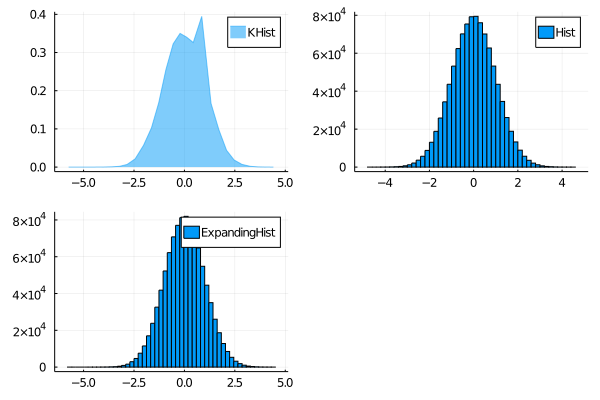

In [2]:
s = fit!(Series(KHist(25), Hist(-5:.2:5), ExpandingHist(100)), randn(10^6))
plot(s, link = :x, label = ["KHist" "Hist" "ExpandingHist"])


In [2]:
using Dates, CSV, Plots, PlotThemes, ProgressMeter
# Interact, HTTP, SingularSpectrumAnalysis, JuliaDB,
using OnlineStats
theme(:bright)

o = Partition(Series(Mean(), Extrema()))

y = randn()

@showprogress for _ in 1:10^3
    fit!(o,  global y += randn())
    plot!(o)
end

# println(o)
# plot(o)


Progress: 100%|█████████████████████████████████████████| Time: 0:00:20


In [6]:
using OnlineStats, CSV, Plots

url = "https://gist.githubusercontent.com/joshday/df7bdaa1d58b398592e7656395de6335/raw/5a1c83f498f8ca7e25ff2372340e44b3389be9b1/iris.csv"
rows = CSV.Rows(open("data/iris.txt"); reusebuffer=true)
# rows = CSV.Rows(download(url); reusebuffer = true)

itr = (row.variety => parse(Float64, row.sepal_length) for row in rows)

o = GroupBy(String, Hist(4:0.25:8))

# fit!(o, itr)
ThreadsX.reduce(o, itr)
plot(o, layout=(3,1))

LoadError: MethodError: no method matching length(::CSV.Rows{false,Parsers.Options{false,false,true,false,Missing,UInt8,Nothing},Nothing,Array{UInt8,1},DataType,UInt64})
Closest candidates are:
  length(!Matched::DataStructures.SparseIntSet) at /home/zhangyong/.julia/packages/DataStructures/DLSxi/src/sparse_int_set.jl:61
  length(!Matched::Base.MethodList) at reflection.jl:872
  length(!Matched::LibGit2.GitBlob) at /buildworker/worker/package_linux64/build/usr/share/julia/stdlib/v1.5/LibGit2/src/blob.jl:3
  ...

┌ Info: Saved animation to 
│   fn = /home/zhangyong/cluster/julia_learn/cluster/stream/tmp.gif
└ @ Plots /home/zhangyong/.julia/packages/Plots/uCh2y/src/animation.jl:104


Plots.AnimatedGif("/home/zhangyong/cluster/julia_learn/cluster/stream/tmp.gif")
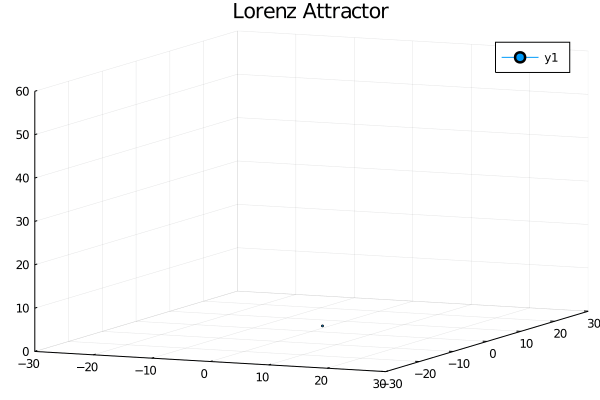

In [1]:

using Plots
# define the Lorenz attractor
Base.@kwdef mutable struct Lorenz
    dt::Float64 = 0.02
    σ::Float64 = 10
    ρ::Float64 = 28
    β::Float64 = 8/3
    x::Float64 = 1
    y::Float64 = 1
    z::Float64 = 1
end

function step!(l::Lorenz)
    dx = l.σ * (l.y - l.x);         l.x += l.dt * dx
    dy = l.x * (l.ρ - l.z) - l.y;   l.y += l.dt * dy
    dz = l.x * l.y - l.β * l.z;     l.z += l.dt * dz
end

attractor = Lorenz()


# initialize a 3D plot with 1 empty series
plt = plot3d(
    1,
    xlim = (-30, 30),
    ylim = (-30, 30),
    zlim = (0, 60),
    title = "Lorenz Attractor",
    marker = 2,
)

# build an animated gif by pushing new points to the plot, saving every 10th frame
@gif for i=1:1500
    step!(attractor)
    push!(plt, attractor.x, attractor.y, attractor.z)
end every 10


In [7]:
ThreadsX.reduce(Mean(), 1:10)


Mean: n=10 | value=5.5